In [1]:
import pandas as pd
import numpy as np

In [2]:
# # Define the column names for the DataFrame
# col_names = ['id', 'mol', 'type', 'q', 'x', 'y', 'z', 'ix', 'iy', 'iz']
# # col_names = ['id', 'mol', 'type', 'x', 'y', 'z', 'xu', 'yu', 'zu']

# # Read the data from the file and store it in a list of lists
# data = []
# with open('Only_type10.lammpstrj') as f:
#     lines = f.readlines()
#     xlo, ylo, zlo = [float(l.split()[0]) for l in lines[5:8]]
#     xhi, yhi, zhi = [float(l.split()[1]) for l in lines[5:8]]
#     L = xhi-xlo
#     for i in range(len(lines)):
#         if 'ITEM: TIMESTEP' in lines[i]:
#             timestep = int(lines[i+1])
#             if timestep > 1000000:
#                 break  # Exit the loop if timestep > 1001000
#             num_particles = int(lines[i+3].split()[0])
#             for j in range(i+9, i+9+num_particles):
#                 line = lines[j]
#                 particle_id, mol, particle_type, q, x, y, z, ix, iy, iz = line.split()
#                 data.append([timestep, particle_id, mol, particle_type, q, x, y, z, ix, iy, iz])

# # Convert the list of lists to a DataFrame
# df = pd.DataFrame(data, columns=['time'] + col_names)

# # Convert the data types of some columns to float
# df[['q', 'x', 'y', 'z']] = df[['q', 'x', 'y', 'z']].astype(float)
# df[['id','mol','type', 'ix', 'iy', 'iz']] = df[['id','mol','type', 'ix', 'iy', 'iz']].astype(int)
# df[['time']] = df[['time']].astype(float)
# df['time']= df['time']/1000
# df


import pandas as pd

# Define column names based on dump header
col_names = ['id', 'mol', 'type', 'x', 'y', 'z', 'xu', 'yu', 'zu']

data = []
with open('Only_type10.lammpstrj') as f:
    lines = f.readlines()
    xlo, ylo, zlo = [float(l.split()[0]) for l in lines[5:8]]
    xhi, yhi, zhi = [float(l.split()[1]) for l in lines[5:8]]
    L = xhi-xlo
    for i in range(len(lines)):
        if 'ITEM: TIMESTEP' in lines[i]:
            timestep = int(lines[i+1])
            if timestep > 1000000:
                break  # stop at timestep cutoff
            num_particles = int(lines[i+3].strip())
            for j in range(i+9, i+9+num_particles):
                parts = lines[j].split()
                particle_id, mol, particle_type, x, y, z, xu, yu, zu = parts
                data.append([timestep, particle_id, mol, particle_type,
                             x, y, z, xu, yu, zu])

# Convert to DataFrame
df = pd.DataFrame(data, columns=['time'] + col_names)

# Convert to proper types
df[['id','mol','type']] = df[['id','mol','type']].astype(int)
df[['x','y','z','xu','yu','zu']] = df[['x','y','z','xu','yu','zu']].astype(float)
df['time'] = df['time'].astype(int) / 1000.0  # ps if 1000 steps = 1 ps

df


,time,id,mol,type,x,y,z,xu,yu,zu
0,0.0,20517,63,10,-25.3675,-29.2514,-8.267640,35.7835,31.8996,52.883400
1,0.0,20505,57,10,-29.0035,-29.0810,-6.040940,32.1475,32.0700,55.110100
2,0.0,20691,150,10,-17.2581,-24.9014,-0.140576,43.8929,36.2496,61.010400
3,0.0,20685,147,10,-18.1481,-27.5898,-3.204780,43.0029,33.5612,57.946200
4,0.0,20423,16,10,-29.7748,-17.5814,-5.331980,31.3762,43.5696,-5.331980
...,...,...,...,...,...,...,...,...,...,...
240235,1000.0,20767,188,10,28.7784,27.5754,0.124191,28.7784,27.5754,0.124191
240236,1000.0,20805,207,10,16.4429,22.2045,26.253700,16.4429,22.2045,26.253700
240237,1000.0,20603,106,10,15.5774,18.4631,24.767500,15.5774,18.4631,24.767500
240238,1000.0,20849,229,10,29.6255,21.1035,26.409300,29.6255,21.1035,26.409300


In [3]:
len(df)
print(L)
df

61.150995639245934


,time,id,mol,type,x,y,z,xu,yu,zu
0,0.0,20517,63,10,-25.3675,-29.2514,-8.267640,35.7835,31.8996,52.883400
1,0.0,20505,57,10,-29.0035,-29.0810,-6.040940,32.1475,32.0700,55.110100
2,0.0,20691,150,10,-17.2581,-24.9014,-0.140576,43.8929,36.2496,61.010400
3,0.0,20685,147,10,-18.1481,-27.5898,-3.204780,43.0029,33.5612,57.946200
4,0.0,20423,16,10,-29.7748,-17.5814,-5.331980,31.3762,43.5696,-5.331980
...,...,...,...,...,...,...,...,...,...,...
240235,1000.0,20767,188,10,28.7784,27.5754,0.124191,28.7784,27.5754,0.124191
240236,1000.0,20805,207,10,16.4429,22.2045,26.253700,16.4429,22.2045,26.253700
240237,1000.0,20603,106,10,15.5774,18.4631,24.767500,15.5774,18.4631,24.767500
240238,1000.0,20849,229,10,29.6255,21.1035,26.409300,29.6255,21.1035,26.409300


In [5]:

df['xi'] = (df['xu']-df['x'])/L
df['yi'] = (df['yu']-df['y'])/L
df['zi'] = (df['zu']-df['z'])/L
df['xa'] = df['xu']+df['xu']*df['xi'].astype(float)
df['ya'] = df['yu']+df['yu']*df['yi'].astype(float)
df['za'] = df['zu']+df['zu']*df['zi'].astype(float)
df


,time,id,mol,type,x,y,z,xu,yu,zu,xi,yi,zi,xa,ya,za
0,0.0,20517,63,10,-25.3675,-29.2514,-8.267640,35.7835,31.8996,52.883400,1.0,1.0,1.000001,71.567003,63.799202,105.766838
1,0.0,20505,57,10,-29.0035,-29.0810,-6.040940,32.1475,32.0700,55.110100,1.0,1.0,1.000001,64.295002,64.140002,110.220240
2,0.0,20691,150,10,-17.2581,-24.9014,-0.140576,43.8929,36.2496,61.010400,1.0,1.0,1.000000,87.785803,72.499203,122.020780
3,0.0,20685,147,10,-18.1481,-27.5898,-3.204780,43.0029,33.5612,57.946200,1.0,1.0,1.000000,86.005803,67.122402,115.892385
4,0.0,20423,16,10,-29.7748,-17.5814,-5.331980,31.3762,43.5696,-5.331980,1.0,1.0,0.000000,62.752402,87.139203,-5.331980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240235,1000.0,20767,188,10,28.7784,27.5754,0.124191,28.7784,27.5754,0.124191,0.0,0.0,0.000000,28.778400,27.575400,0.124191
240236,1000.0,20805,207,10,16.4429,22.2045,26.253700,16.4429,22.2045,26.253700,0.0,0.0,0.000000,16.442900,22.204500,26.253700
240237,1000.0,20603,106,10,15.5774,18.4631,24.767500,15.5774,18.4631,24.767500,0.0,0.0,0.000000,15.577400,18.463100,24.767500
240238,1000.0,20849,229,10,29.6255,21.1035,26.409300,29.6255,21.1035,26.409300,0.0,0.0,0.000000,29.625500,21.103500,26.409300


In [6]:
print(len(df))
print(num_particles)
print(int(len(df)/num_particles-1))

240240
240
1000


In [19]:
R1_list=[]
size=[]
dx_list =[]
dy_list =[]
dz_list =[]

for i in range(int(len(df)/num_particles-1)):
    dx = df[df.time == i+1]['xa'].reset_index().drop(columns=['index']) - df[df.time == i]['xa'].reset_index().drop(columns=['index'])
    dy = df[df.time == i+1]['ya'].reset_index().drop(columns=['index']) - df[df.time == i]['ya'].reset_index().drop(columns=['index'])
    dz = df[df.time == i+1]['za'].reset_index().drop(columns=['index']) - df[df.time == i]['za'].reset_index().drop(columns=['index'])
    
    dr = ((dx.values**2 + dy.values**2 + dz.values**2)**0.5)
    R1_list.append(dr)


    
R10_list=[]

for i in range(int(len(df)/num_particles-10)):
    dx = df[df.time == i+10]['xa'].reset_index().drop(columns=['index']) - df[df.time == i]['xa'].reset_index().drop(columns=['index'])
    dy = df[df.time == i+10]['ya'].reset_index().drop(columns=['index']) - df[df.time == i]['ya'].reset_index().drop(columns=['index'])
    dz = df[df.time == i+10]['za'].reset_index().drop(columns=['index']) - df[df.time == i]['za'].reset_index().drop(columns=['index'])
    
    dr = ((dx.values**2 + dy.values**2 + dz.values**2)**0.5)
    R10_list.append(dr)
    size.append(i)
    
R100_list=[]

for i in range(int(len(df)/num_particles-100)):
    dx = df[df.time == i+100]['xa'].reset_index().drop(columns=['index']) - df[df.time == i]['xa'].reset_index().drop(columns=['index'])
    dy = df[df.time == i+100]['ya'].reset_index().drop(columns=['index']) - df[df.time == i]['ya'].reset_index().drop(columns=['index'])
    dz = df[df.time == i+100]['za'].reset_index().drop(columns=['index']) - df[df.time == i]['za'].reset_index().drop(columns=['index'])
    
    dr = ((dx.values**2 + dy.values**2 + dz.values**2)**0.5)
    R100_list.append(dr)


# Rhalf_list=[]
# size=[]
# # dx_list =[]
# # dy_list =[]
# # dz_list =[]

# for i in range(int(len(df)/num_particles-1)):
#     dx = df[df.time == i+0.5]['xa'].reset_index().drop(columns=['index']) - df[df.time == i]['xa'].reset_index().drop(columns=['index'])
#     dy = df[df.time == i+0.5]['ya'].reset_index().drop(columns=['index']) - df[df.time == i]['ya'].reset_index().drop(columns=['index'])
#     dz = df[df.time == i+0.5]['za'].reset_index().drop(columns=['index']) - df[df.time == i]['za'].reset_index().drop(columns=['index'])
    
#     dr = ((dx.values**2 + dy.values**2 + dz.values**2)**0.5)
#     Rhalf_list.append(dr)


    
# R1_list=[]

# for i in range(int(len(df)/num_particles-10)):
#     dx = df[df.time == i+1]['xa'].reset_index().drop(columns=['index']) - df[df.time == i]['xa'].reset_index().drop(columns=['index'])
#     dy = df[df.time == i+1]['ya'].reset_index().drop(columns=['index']) - df[df.time == i]['ya'].reset_index().drop(columns=['index'])
#     dz = df[df.time == i+1]['za'].reset_index().drop(columns=['index']) - df[df.time == i]['za'].reset_index().drop(columns=['index'])
    
#     dr = ((dx.values**2 + dy.values**2 + dz.values**2)**0.5)
#     R1_list.append(dr)
#     size.append(i)
    
# R2_list=[]

# for i in range(int(len(df)/num_particles-100)):
#     dx = df[df.time == i+2]['xa'].reset_index().drop(columns=['index']) - df[df.time == i]['xa'].reset_index().drop(columns=['index'])
#     dy = df[df.time == i+2]['ya'].reset_index().drop(columns=['index']) - df[df.time == i]['ya'].reset_index().drop(columns=['index'])
#     dz = df[df.time == i+2]['za'].reset_index().drop(columns=['index']) - df[df.time == i]['za'].reset_index().drop(columns=['index'])
    
#     dr = ((dx.values**2 + dy.values**2 + dz.values**2)**0.5)
#     R2_list.append(dr)




In [25]:
R1_resultList = []
R10_resultList =[]
R100_resultList =[]

# Traversing in till the length of the input list of lists
for m in range(len(R1_list)):

   # using nested for loop, traversing the inner lists
   for n in range (len(R1_list[m])):

      # Add each element to the result list
      R1_resultList.append(R1_list[m][n])
        
for m in range(len(R10_list)):

   # using nested for loop, traversing the inner lists
   for n in range (len(R10_list[m])):

      # Add each element to the result list
      R10_resultList.append(R10_list[m][n])
        
for m in range(len(R100_list)):

   # using nested for loop, traversing the inner lists
   for n in range (len(R100_list[m])):

      # Add each element to the result list
      R100_resultList.append(R100_list[m][n])
        

print(R1_resultList[0:5])
print(R10_resultList[0:5])

[array([1.26341006]), array([1.98658858]), array([9.12023537]), array([117.44715802]), array([1.77513089])]
[array([2.01924656]), array([25.38766304]), array([26.75621924]), array([2.74551673]), array([2.05914466])]


/var/folders/3y/kvyy9f_d1mv5m2bhy9vzprqm0000gp/T/ipykernel_8724/3815220340.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(R1_resultList,bins=bins,label = "1 ps", color='red', hist_kws={"histtype": "step", "linewidth":1.0,"alpha": 1, "color": "r"}, kde_kws={"linewidth":0})
/var/folders/3y/kvyy9f_d1mv5m2bhy9vzprqm0000gp/T/ipykernel_8724/3815220340.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use 

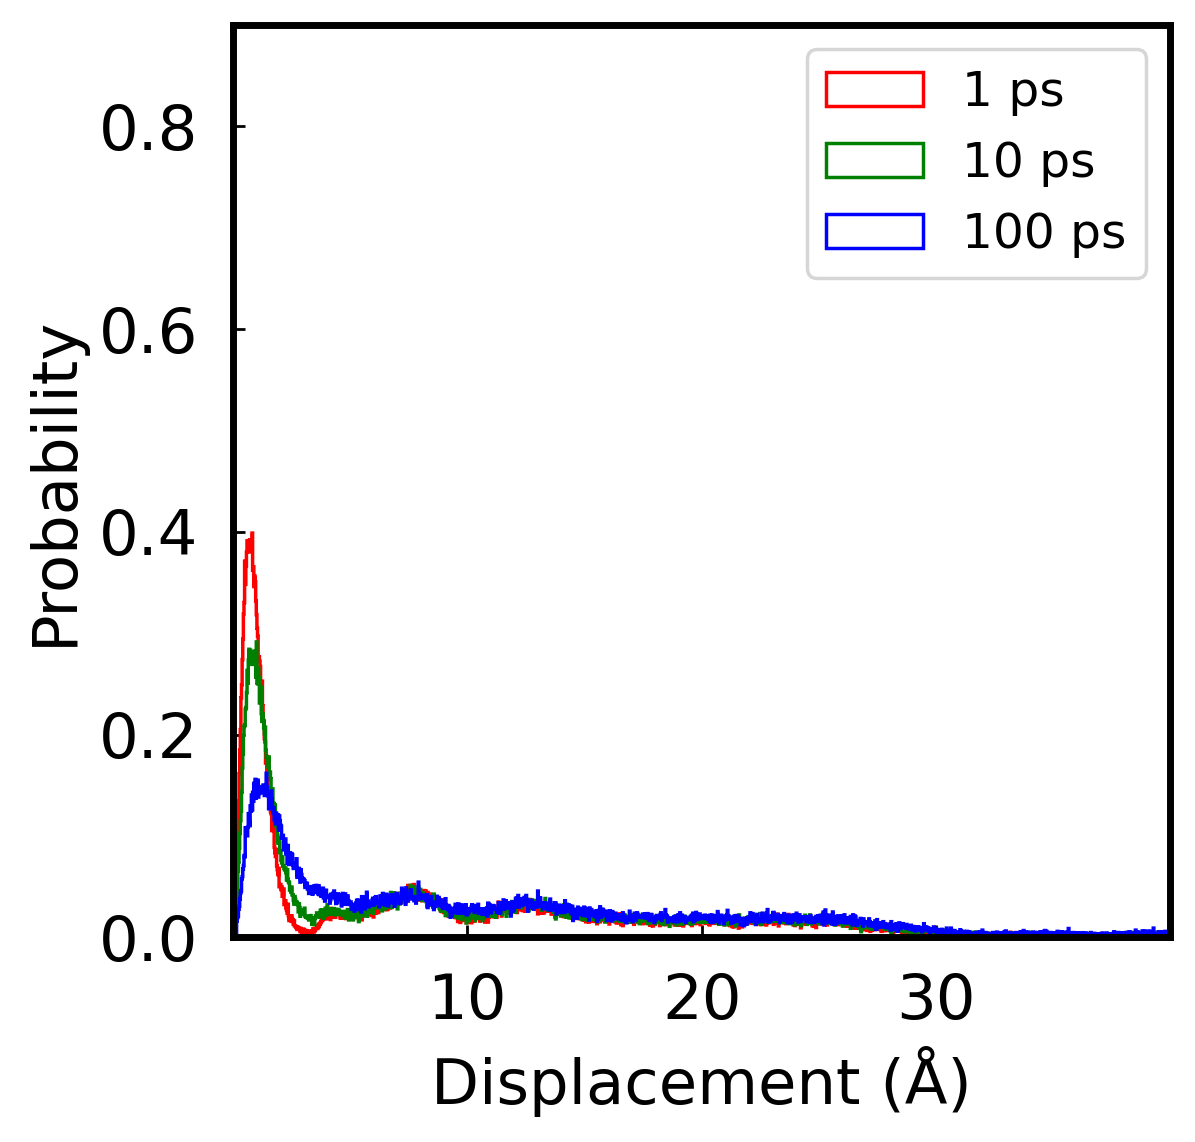

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(5,5),dpi=250)

# plt.title("PS 500K")
bins = np.linspace(-2,40,1600)

sns.distplot(R1_resultList,bins=bins,label = "1 ps", color='red', hist_kws={"histtype": "step", "linewidth":1.0,"alpha": 1, "color": "r"}, kde_kws={"linewidth":0})
sns.distplot(R10_resultList,bins=bins,label = "10 ps",kde=True,color='green',hist_kws={"histtype": "step", "linewidth":1.0,"alpha": 1, "color": "g"},kde_kws={"linewidth":0})
sns.distplot(R100_resultList,bins=bins,label = "100 ps",kde=True,color='blue',hist_kws={"histtype": "step", "linewidth":1.0,"alpha": 1, "color": "b"},kde_kws={"linewidth":0})


plt.xlim([0,40])
plt.ylim([0,0.9])
plt.xticks(np.arange(10, 40, 10), fontsize=18)
plt.yticks(np.arange(0, 0.9, 0.2), fontsize=18)

plt.xlabel("Displacement (Å)", fontsize=18)
plt.ylabel("Probability", fontsize=18)
plt.legend(fontsize=14)
plt.subplots_adjust(left=0.15, bottom=0.15)


plt.gca().spines['left'].set_linewidth(2)
plt.gca().spines['bottom'].set_linewidth(2)
plt.gca().spines['right'].set_linewidth(2)
plt.gca().spines['top'].set_linewidth(2)
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams.update({'font.size': 20})
plt.tick_params(axis='both', which='both', direction='in', pad=10)

plt.savefig("displacement_distribution.png", dpi=300, bbox_inches='tight')  # PNG format
plt.savefig("displacement_distribution.pdf", dpi=300, bbox_inches='tight') 

plt.show()

# 